# Utilizing KMeans Clustering for Customer Segmentation

## Scenario Introduction

In this work, we act as a data scientist working for a credit card company. The task is to implement a KMeans algorithm to segment customers into groups such that different business strategies can be applied for each customer type. 

We are provided with a mostly clean customer dataset which contains personal and financial information for all customers registered with the credit card company.

### Deliverables

The company expects to receive:

1. A table of customer_ids and the group that each customer has been assigned
2. An explanation of the characteristics of each group and what sets each group apart from one another

---
## Contents

* [Dataset EDA](#exploratory-data-analysis-eda)
* [Feature Engineering](#feature-engineering)
* [Preprocessing](#preprocessing-scaling)
* [Model Fitting and identification of the most appropriate number of clusters](#fitting-the-model-k-selection)
* [Segment the data](#segmenting-the-customer-data) (achieves deliverable 1)
* [Interpretation and Explanation of the group assignments](#interpreting-the-results) (achieves deliverable 2)
* [Final Results](#cluster-characteristics)

## Data Dictionary

A data dictionary for the `customer_segmentation.csv` dataset is given below:

| Column                    | Description                                                                                                             |
|---------------------------|-------------------------------------------------------------------------------------------------------------------------|
| customer_id               | unique identifier for each customer                                                                                     |
| age                       | age of customer (years)                                                                                                 |
| gender                    | gender of customer (M or F)                                                                                             |
| dependent_count           | number of dependents each customer has                                                                                  |
| education_level           | level of education ("High School", "Graduate", ...)                                                                     |
| marital_status            | marital status ("Single", "Married", ...)                                                                               |
| estimated_income          | the estimated income for the customer projected by the data science team                                                |
| months_on_book            | the number of months the individual has been a customer                                                                 |
| total_relationship_count  | the number of times the customer has contacted the credit company                                                       |
| months_inactive_12_mon    | the number of months the customer did not use their credit card (in the previous 12 months)                             |
| credit_limit              | the customer's credit limit                                                                                             |
| total_trans_amount        | the total amount of money spent on the credit card by the customer                                                      |
| total_trans_count         | the total number of times the customer used their credit card                                                           |
| avg_utilization_ratio     | the average utilization ratio (average proportion of the customer's available credit they use) |                                                                                   

# Exploratory Data Analysis: EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

np.random.seed(36)
sns.set_style("whitegrid")

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

customers = pd.read_csv("customer_segmentation.csv")
customers.head()

,customer_id,age,gender,dependent_count,education_level,marital_status,estimated_income,months_on_book,total_relationship_count,months_inactive_12_mon,credit_limit,total_trans_amount,total_trans_count,avg_utilization_ratio
0,768805383,45,M,3,High School,Married,69000,39,5,1,12691.0,1144,42,0.061
1,818770008,49,F,5,Graduate,Single,24000,44,6,1,8256.0,1291,33,0.105
2,713982108,51,M,3,Graduate,Married,93000,36,4,1,3418.0,1887,20,0.000
3,769911858,40,F,4,High School,Unknown,37000,34,3,4,3313.0,1171,20,0.760
4,709106358,40,M,3,Uneducated,Married,65000,21,5,1,4716.0,816,28,0.000


In [2]:
customers.shape

(10127, 14)

The dataset contains 10,127 records and 14 columns. Only 13 of the columns are to be considered as features for the clustering algorithm (since the `customer_id` field is a unique identifier, hence is not relevant to the segmentation).

In [3]:
nulls = customers.isnull().sum()
nulls

customer_id                 0
age                         0
gender                      0
dependent_count             0
education_level             0
marital_status              0
estimated_income            0
months_on_book              0
total_relationship_count    0
months_inactive_12_mon      0
credit_limit                0
total_trans_amount          0
total_trans_count           0
avg_utilization_ratio       0
dtype: int64

The dataset does not contain any null values. 

We must also verify the distributions of each column to ensure all values are reasonable:

In [4]:
numeric_summary = customers.describe()
numeric_summary

,customer_id,age,dependent_count,estimated_income,months_on_book,total_relationship_count,months_inactive_12_mon,credit_limit,total_trans_amount,total_trans_count,avg_utilization_ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,62078.206774,35.928409,3.812580,2.341167,8631.953698,4404.086304,64.858695,0.274894
std,3.690378e+07,8.016814,1.298908,39372.861291,7.986416,1.554408,1.010622,9088.776650,3397.129254,23.472570,0.275691
min,7.080821e+08,26.000000,0.000000,20000.000000,13.000000,1.000000,0.000000,1438.300000,510.000000,10.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,32000.000000,31.000000,3.000000,2.000000,2555.000000,2155.500000,45.000000,0.023000
50%,7.179264e+08,46.000000,2.000000,50000.000000,36.000000,4.000000,2.000000,4549.000000,3899.000000,67.000000,0.176000
75%,7.731435e+08,52.000000,3.000000,80000.000000,40.000000,5.000000,3.000000,11067.500000,4741.000000,81.000000,0.503000
max,8.283431e+08,73.000000,5.000000,200000.000000,56.000000,6.000000,6.000000,34516.000000,18484.000000,139.000000,0.999000


In [5]:
categorical_summary = customers.describe(include="str")
categorical_summary

,gender,education_level,marital_status
count,10127,10127,10127
unique,2,6,4
top,F,Graduate,Married
freq,5358,3685,4687


All numerical and categorical columns contain datapoints that are within a sensible range.

In [6]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10127 non-null  int64  
 1   age                       10127 non-null  int64  
 2   gender                    10127 non-null  str    
 3   dependent_count           10127 non-null  int64  
 4   education_level           10127 non-null  str    
 5   marital_status            10127 non-null  str    
 6   estimated_income          10127 non-null  int64  
 7   months_on_book            10127 non-null  int64  
 8   total_relationship_count  10127 non-null  int64  
 9   months_inactive_12_mon    10127 non-null  int64  
 10  credit_limit              10127 non-null  float64
 11  total_trans_amount        10127 non-null  int64  
 12  total_trans_count         10127 non-null  int64  
 13  avg_utilization_ratio     10127 non-null  float64
dtypes: float64(2), in

### Summarizing Categorical Columns

In [7]:
categorical_columns = categorical_summary.columns.tolist()

frequency_tables = []

for col in categorical_columns:
  
  frequency_table = (customers[col].value_counts()).to_frame()
  
  frequency_table["percentage"] = round((frequency_table["count"] / frequency_table["count"].sum()) * 100, 1)
  
  frequency_tables.append(frequency_table)

gender_freq = frequency_tables[0]
education_freq = frequency_tables[1]
marital_status_freq = frequency_tables[2]

In [8]:
gender_freq

,count,percentage
gender,,
F,5358,52.9
M,4769,47.1


In [9]:
education_freq

,count,percentage
education_level,,
Graduate,3685,36.4
High School,2351,23.2
Uneducated,1755,17.3
College,1192,11.8
Post-Graduate,616,6.1
Doctorate,528,5.2


In [10]:
marital_status_freq

,count,percentage
marital_status,,
Married,4687,46.3
Single,3943,38.9
Unknown,749,7.4
Divorced,748,7.4


### Visualizing Categorical Column Distribution

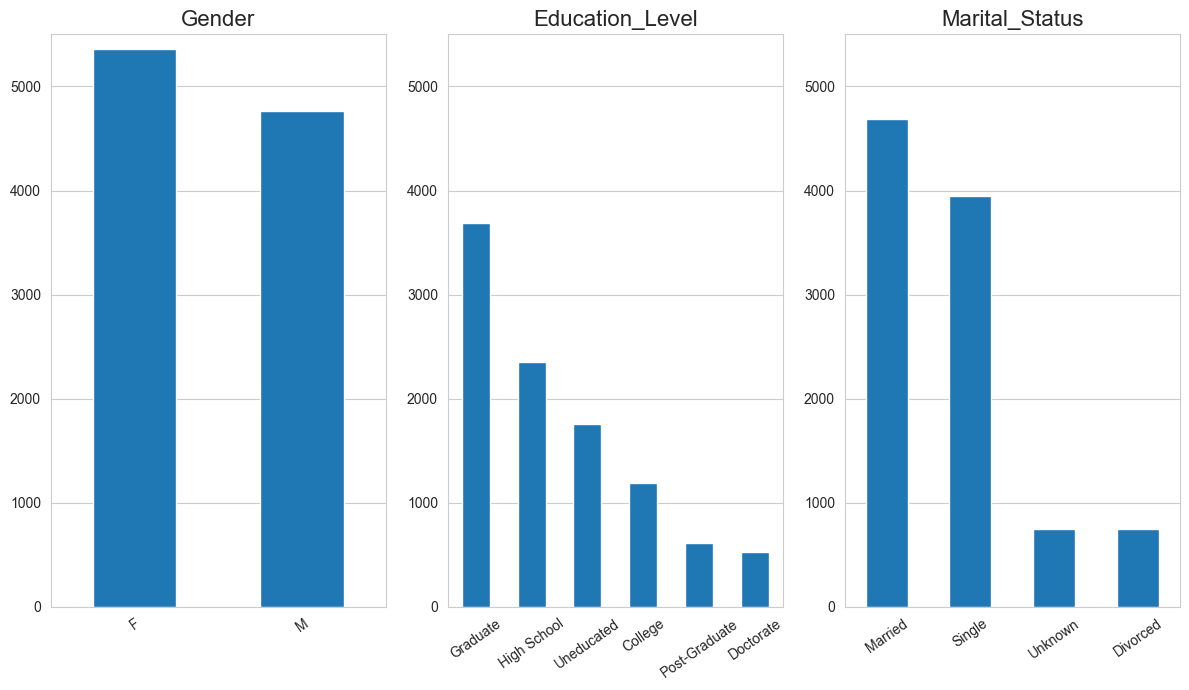

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 7))

ax = axes.ravel()  # convert 2D array to 1D, required to plot on subplots

for i, frequency_table in enumerate(frequency_tables):
  plt.subplot(1, 3, i+1)
  frequency_table["count"].plot.bar(rot=35, legend=False, ax=ax[i])
  ax[i].set_title(categorical_columns[i].title(), fontsize=16)
  ax[i].set_xlabel("")
  ax[i].set_ylim(0, 5500)
  ax[i].xaxis.grid(False)
  
plt.tight_layout()
plt.show()

Above, we uncover insights into the distribution of the categorical variables.

* There is a slight majority of female customers (52.9%)
* 47.7% of customers have graduated from a college level course
* The majority of customers are married (46.3%), closely followed by single (38.9%)

### Visualizing Numerical Column Distribution

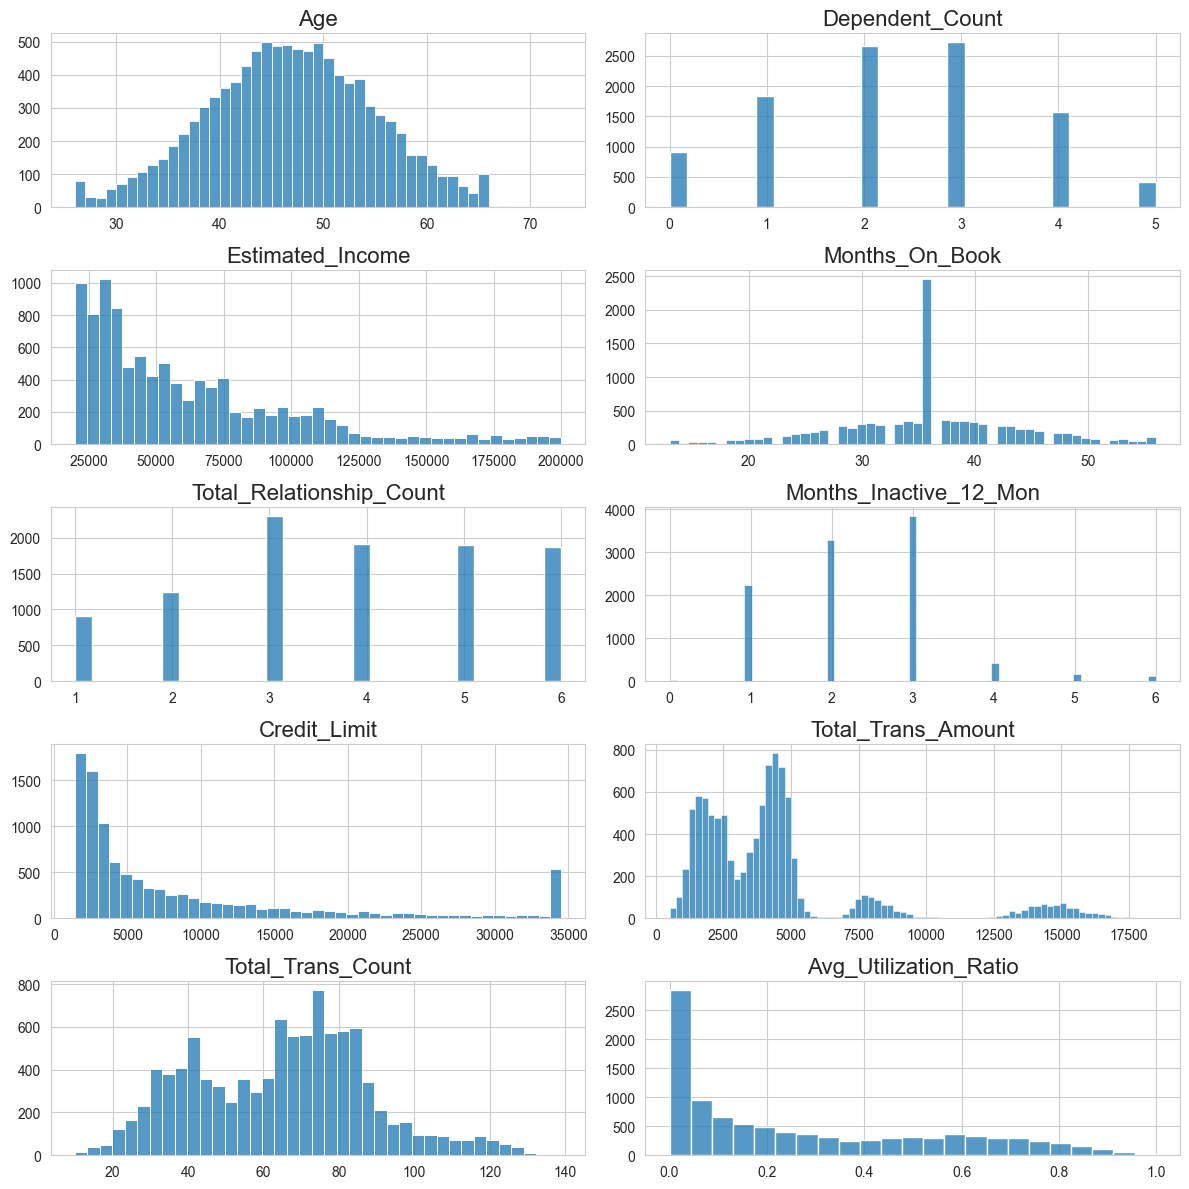

In [12]:
numeric_columns = numeric_summary.columns.tolist()
numeric_columns.remove("customer_id")

plt.figure(figsize=(12, 12))

for i, col in enumerate(numeric_columns):
  
  plt.subplot(5, 2, i+1)
  sns.histplot(customers[col])
  plt.xlabel("")
  plt.ylabel("")
  plt.title(col.title(), fontsize=16)

plt.tight_layout()
plt.show()

A number of columns are near-normal distributions (`age`, `dependent_count`, `total_trans_count`, `months_on_book`), however, many show significant skew:

* Right skew: `credit_limit`, `avg_utilization_ratio`, `estimated_income`, `total_trans_amount`, `months_inactive_12_mon`
* Left skew: `total_relationship_count`

There is also evidence of multi-modality in the `total_trans_amount` and `total_trans_count` distribution. There are four discernable peaks across the range of values of the `trans_amount` distribution and two in the `trans_count` distribution.

### Mapping Pearson's Correlation Coefficient for Numeric Variables

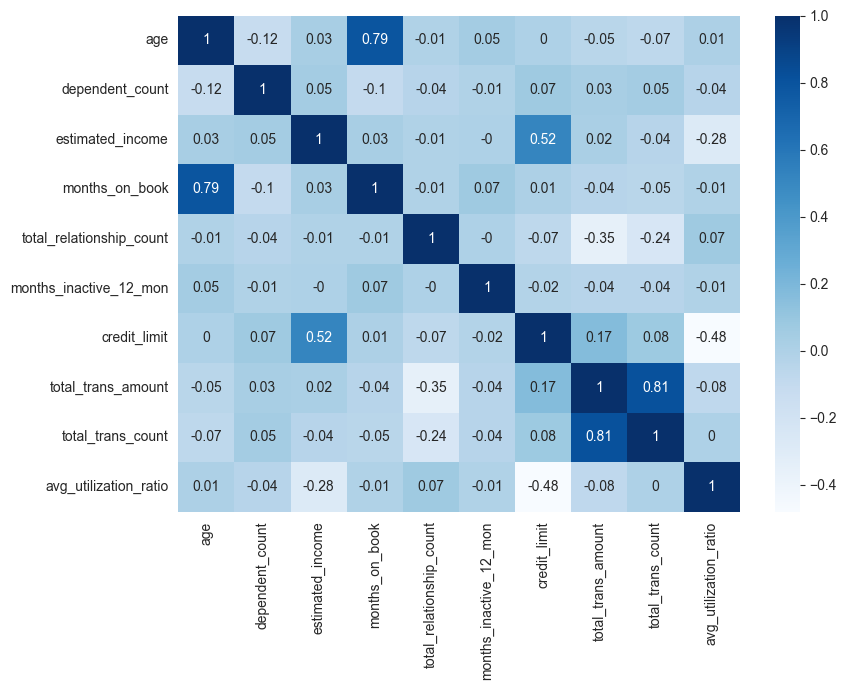

In [13]:
plt.figure(figsize=(9, 7))

sns.heatmap(round(customers[numeric_columns].corr(), 2), cmap="Blues", annot=True)

plt.tight_layout()
plt.show()

Many of the linear relationships are weak, though some strong associations exist.

Important relationships:

* `Age` is strongly correlated to `months_on_book`: 
  - An older person is likely to have been a customer with the credit company for a greater period of time compared to a young person.

* `Credit_limit` is positively correlated with `estimated_income` and negatively correlated with `avg_utilization_ratio`:
  - Customers with larger projected incomes typically have greater credit limits.
  - Customers with a large utilization ratio will typically have smaller credit limits.

* `Total_trans_amount` is strongly correlated to `total_trans_count`:
  - Customers that use their credit card(s) frequently are likely to have a large total transaction amount.



## Feature Engineering

To fit the KMeans algorithm, the categorical columns must be handled.

* `gender` - can be encoded with numbers (1 for Male, 0 for Female)
* `education_level` - an ordinal variable, can be mapped with numbers from 0 to 5 (where 0 is the lowest level of education and 5 is the greatest)
* `marital_status` - can be one-hot encoded by creating dummy varibales


In [14]:
customers_modif = customers.copy() # make a copy of the original dataset. the original dataset is to be used for interpretation of results

map_dict = {
  "Uneducated": 0,
  "High School": 1,
  "College": 2,
  "Graduate": 3,
  "Post-Graduate": 4,
  "Doctorate": 5
}

customers_modif["gender"] = customers_modif["gender"].apply(lambda x: 1 if x == "M" else 0)
customers_modif["education_level"] = customers_modif["education_level"].map(map_dict)
customers_modif = pd.get_dummies(customers_modif, columns=["marital_status"], drop_first=True)

customers_modif.head()

,customer_id,age,gender,dependent_count,education_level,estimated_income,months_on_book,total_relationship_count,months_inactive_12_mon,credit_limit,total_trans_amount,total_trans_count,avg_utilization_ratio,marital_status_Married,marital_status_Single,marital_status_Unknown
0,768805383,45,1,3,1,69000,39,5,1,12691.0,1144,42,0.061,True,False,False
1,818770008,49,0,5,3,24000,44,6,1,8256.0,1291,33,0.105,False,True,False
2,713982108,51,1,3,3,93000,36,4,1,3418.0,1887,20,0.000,True,False,False
3,769911858,40,0,4,1,37000,34,3,4,3313.0,1171,20,0.760,False,False,True
4,709106358,40,1,3,0,65000,21,5,1,4716.0,816,28,0.000,True,False,False


## Preprocessing: Scaling

Before fitting the data to the algorithm, the dataset should be standardized to ensure the range of values for each feature are of a comparable magnitude. This is important to ensure no unintended penalization occurs because of the mismatch in order of magnitude between variables. 

In [15]:
scaler = StandardScaler()

X = customers_modif.copy()

X = X.drop(["customer_id"], axis=1)

X_scaled = pd.DataFrame(scaler.fit_transform(X))

X_scaled.head(3)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,-0.165406,1.059956,0.503368,-0.752211,0.175810,0.384621,0.763943,-1.327136,0.446622,-0.959707,-0.973895,-0.775882,1.077338,-0.798507,-0.282609
1,0.333570,-0.943436,2.043199,0.662787,-0.967166,1.010715,1.407306,-1.327136,-0.041367,-0.916433,-1.357340,-0.616276,-0.928214,1.252337,-0.282609
2,0.583058,1.059956,0.503368,0.662787,0.785397,0.008965,0.120579,-1.327136,-0.573698,-0.740982,-1.911206,-0.997155,1.077338,-0.798507,-0.282609


## Fitting the Model: K Selection

The scaled data is ready to be fitted to the KMeans algorithm. To establish a suitable value for the number of clusters, $k$, the **elbow rule** can be used.

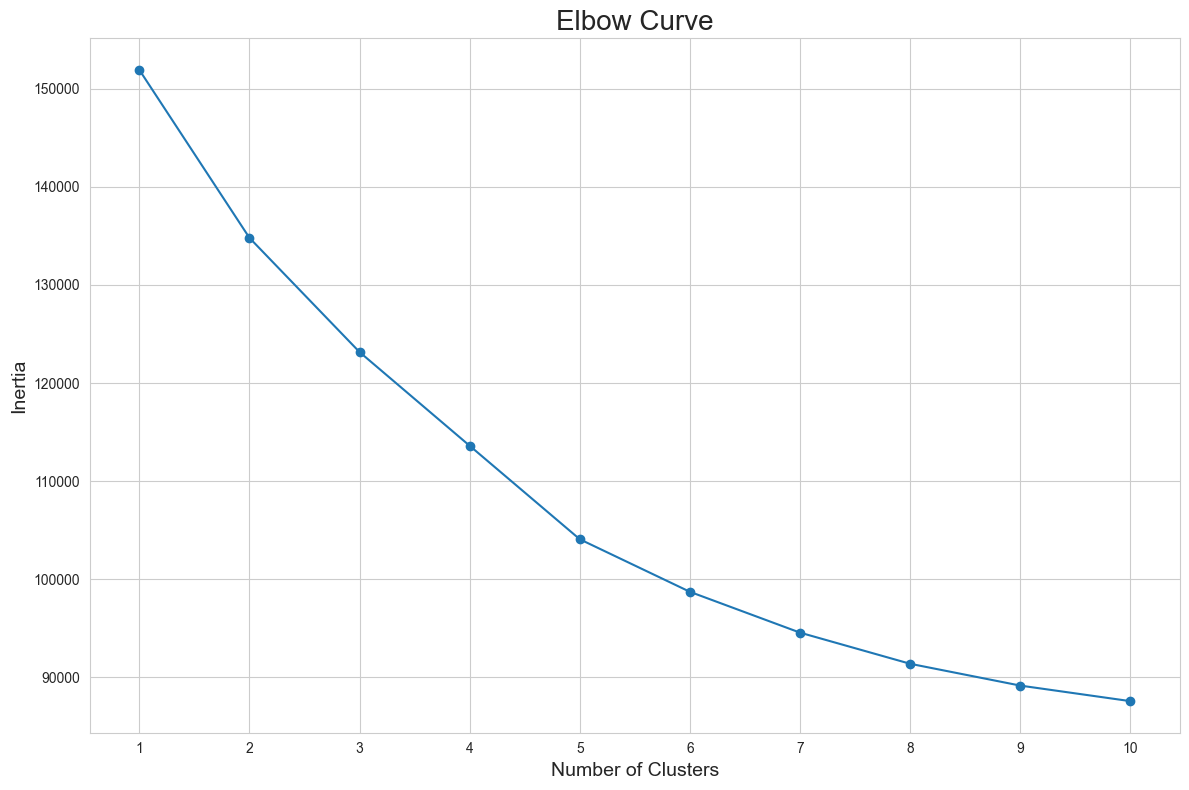

In [16]:
k = list(range(1, 11))

inertias = []

for i in k:
  model = KMeans(n_clusters=i)
  y = model.fit_predict(X_scaled)
  
  inertias.append(model.inertia_)

plt.figure(figsize=(12, 8))

plt.plot(k, inertias, marker="o")

plt.xlabel("Number of Clusters", fontsize=14)
plt.ylabel("Inertia", fontsize=14)
plt.xticks(k)
plt.title("Elbow Curve", fontsize=20)

plt.tight_layout()
plt.show()

Although no sharp elbow is apparent from the elbow curve, the rate of inertia decrease slows between 5 and 7 clusters. We can select `k = 6` as this is a relatively small number of clusters with a low inertia.

## Segmenting the Customer Data

Using six clusters, we can segment the data to obtain an array of labels for every observation in the scaled dataset. This can be used to label each of the records in the original `customers` dataset to group each customer into one of the clusters.

In [17]:
model = KMeans(n_clusters=6)

clusters = model.fit_predict(X_scaled)

inertia = model.inertia_

print(f"Clusters: {clusters}")
print(f"Inertia: {inertia}")

customers["cluster"] = clusters + 1

customers.head()

Clusters: [1 3 1 ... 4 0 4]
Inertia: 98724.83512118508


,customer_id,age,gender,dependent_count,education_level,marital_status,estimated_income,months_on_book,total_relationship_count,months_inactive_12_mon,credit_limit,total_trans_amount,total_trans_count,avg_utilization_ratio,cluster
0,768805383,45,M,3,High School,Married,69000,39,5,1,12691.0,1144,42,0.061,2
1,818770008,49,F,5,Graduate,Single,24000,44,6,1,8256.0,1291,33,0.105,4
2,713982108,51,M,3,Graduate,Married,93000,36,4,1,3418.0,1887,20,0.000,2
3,769911858,40,F,4,High School,Unknown,37000,34,3,4,3313.0,1171,20,0.760,1
4,709106358,40,M,3,Uneducated,Married,65000,21,5,1,4716.0,816,28,0.000,5


In [18]:
ids_clusters = customers[["customer_id", "cluster"]]
ids_clusters

,customer_id,cluster
0,768805383,2
1,818770008,4
2,713982108,2
3,769911858,1
4,709106358,5
...,...,...
10122,772366833,6
10123,710638233,5
10124,716506083,5
10125,717406983,1


We have achieved the first deliverable for this work.

## Interpreting the Results

To conclude our work, the characteristics of customers within each cluster must be found - what makes the customers in one cluster different to customers in another?

In [19]:
cluster_distribution = pd.DataFrame(customers["cluster"].value_counts())

cluster_distribution["percentage"] = round(cluster_distribution["count"] / len(customers) * 100, 1)

cluster_distribution.sort_index(ascending=True)

,count,percentage
cluster,,
1,729,7.2
2,1783,17.6
3,1444,14.3
4,2447,24.2
5,2815,27.8
6,909,9.0


From the above, we see:

* The majority of customers fall into cluster 4 and 5 - 52.0% of all customers. 
* Clusters 2 and 3 are the next largest, making up 31.9% of the customer base.
* Clusters 1 and 6 are the smallest, only comprising 16.2% of the customer base. 

### Average Values by Cluster

To gain an insight into how each cluster differs from the next, we can aggregate the original dataset by the cluster column and find the mean for each feature. A bar chart visualization allows for simple interpretation.

In [20]:
numeric_columns_by_cluster = customers.groupby("cluster")[numeric_columns].mean()

numeric_columns_by_cluster

,age,dependent_count,estimated_income,months_on_book,total_relationship_count,months_inactive_12_mon,credit_limit,total_trans_amount,total_trans_count,avg_utilization_ratio
cluster,,,,,,,,,,
1,45.662551,2.547325,61629.629630,35.292181,3.810700,2.336077,9156.957613,4434.519890,65.825789,0.259469
2,46.818284,2.573752,114480.650589,36.269209,4.053281,2.370723,20187.634773,3293.691531,56.778463,0.074594
3,57.287396,1.150970,50685.595568,46.115651,4.078255,2.440443,4872.093213,2889.513158,53.029086,0.348855
4,43.671026,2.483449,46871.270944,33.519412,3.920311,2.329383,4928.961749,3763.901512,65.313854,0.329049
5,43.195027,2.656838,45853.641208,32.991474,3.959147,2.330373,4369.838082,3556.047957,61.829485,0.355563
6,45.322332,2.305831,68929.592959,35.167217,2.176018,2.194719,14684.547855,13313.273927,106.880088,0.167058


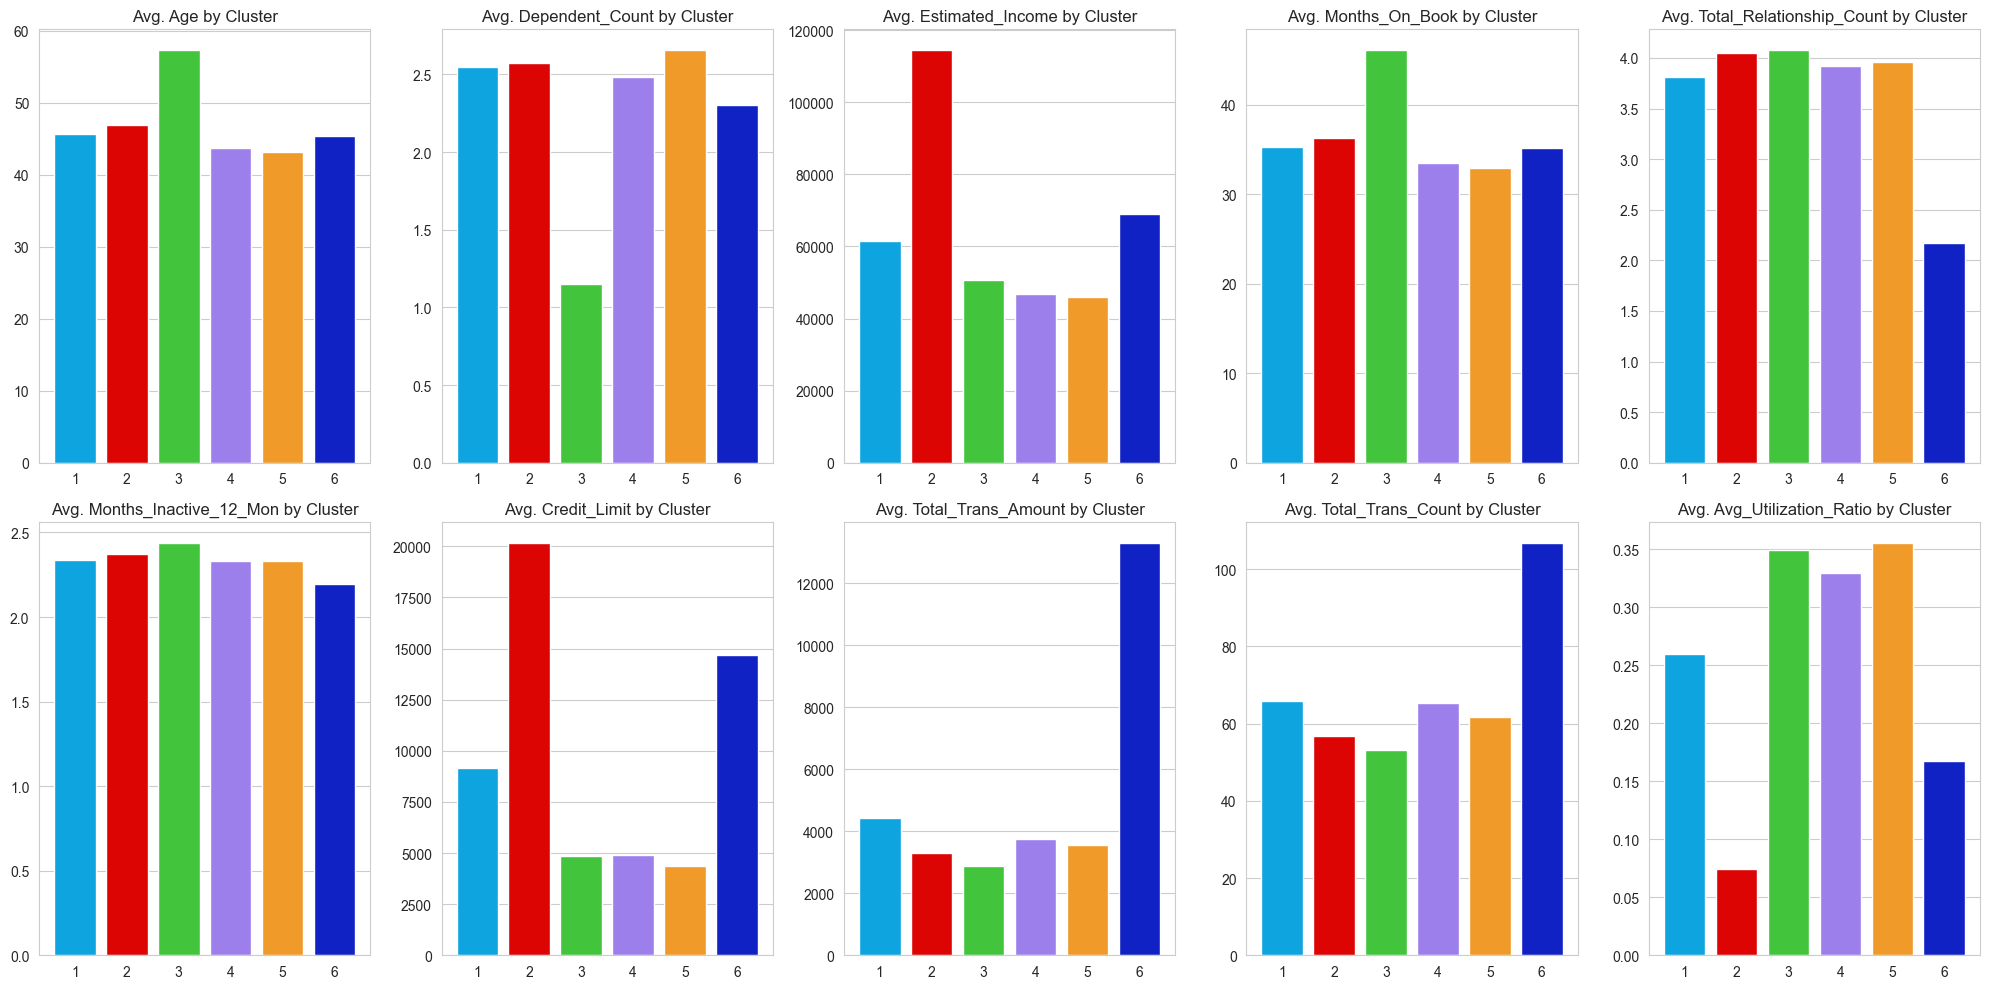

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))

ax = axes.ravel()

for i, col in enumerate(numeric_columns):
  
  plt.subplot(2, 5, i+1)
  
  ax[i].set_title(f"Avg. {col.title()} by Cluster", fontsize=12)
  ax[i].bar(numeric_columns_by_cluster.index, numeric_columns_by_cluster[col], color=["#0da4e0", "#dd0404", "#42c43d", "#9c7feb", "#f09a29", "#1022c4"])
  ax[i].set_xticks(numeric_columns_by_cluster.index)
  ax[i].xaxis.grid(False)
  
plt.tight_layout()
plt.show()

## Cluster Characteristics: Numerical Columns

The key characteristics of each cluster determined from the numeric columns are listed below. The values in the brackets indicate the average value for the associated variable for that cluster.

**Cluster 1 (7.2% of the customer base)**

* Moderate income customers (US$60,000)
* Modest credit limits (US$9,157)
* Relatively large utilization ratios (0.259)

**Cluster 2 (17.6% of the customer base)**

* High income customers (US$114,480)
* Large credit limits (US$20,188)
* Lowest utilization ratios (0.075)

**Cluster 3 (14.3% of the customer base)**

* Older people (57.3 years old)
* Customers that have been on the books for the longest (46.1 months)
* Customers with the fewest number of dependents (1.15)
* Relatively low income customers (US$50,686)
* Low credit limits (US$4,872)
* Large utilization ratios (0.349)

**Cluster 4 (24.2% of the customer base)**

* Low income customers (US$46,871)
* Low credit limits (US$4,929)
* Large utilization ratios (0.329)

**Cluster 5 (27.8% of the customer base)**

* Customers with the greatest number of dependents (2.66)
* Low income customers (US$45,854)
* Low credit limits (US$4,370)
* Large utilization ratios (0.356)

**Cluster 6 (9.0% of the customer base)**

* Relatively high income customers (US$68,930)
* Customers who have contacted the company the least (2.18 times)
* Relatively high credit limits (US$14,685)
* Customers who use their card(s) most frequently (108.9 transactions)
* Customers with the largest transaction amounts (US$13,313)
* Moderate utilization ratios (0.167)

---

For variables that showed significant linear correlation identified in the EDA section, we can visualize this correlation grouped by cluster to gain insight into how these variables change over each cluster.


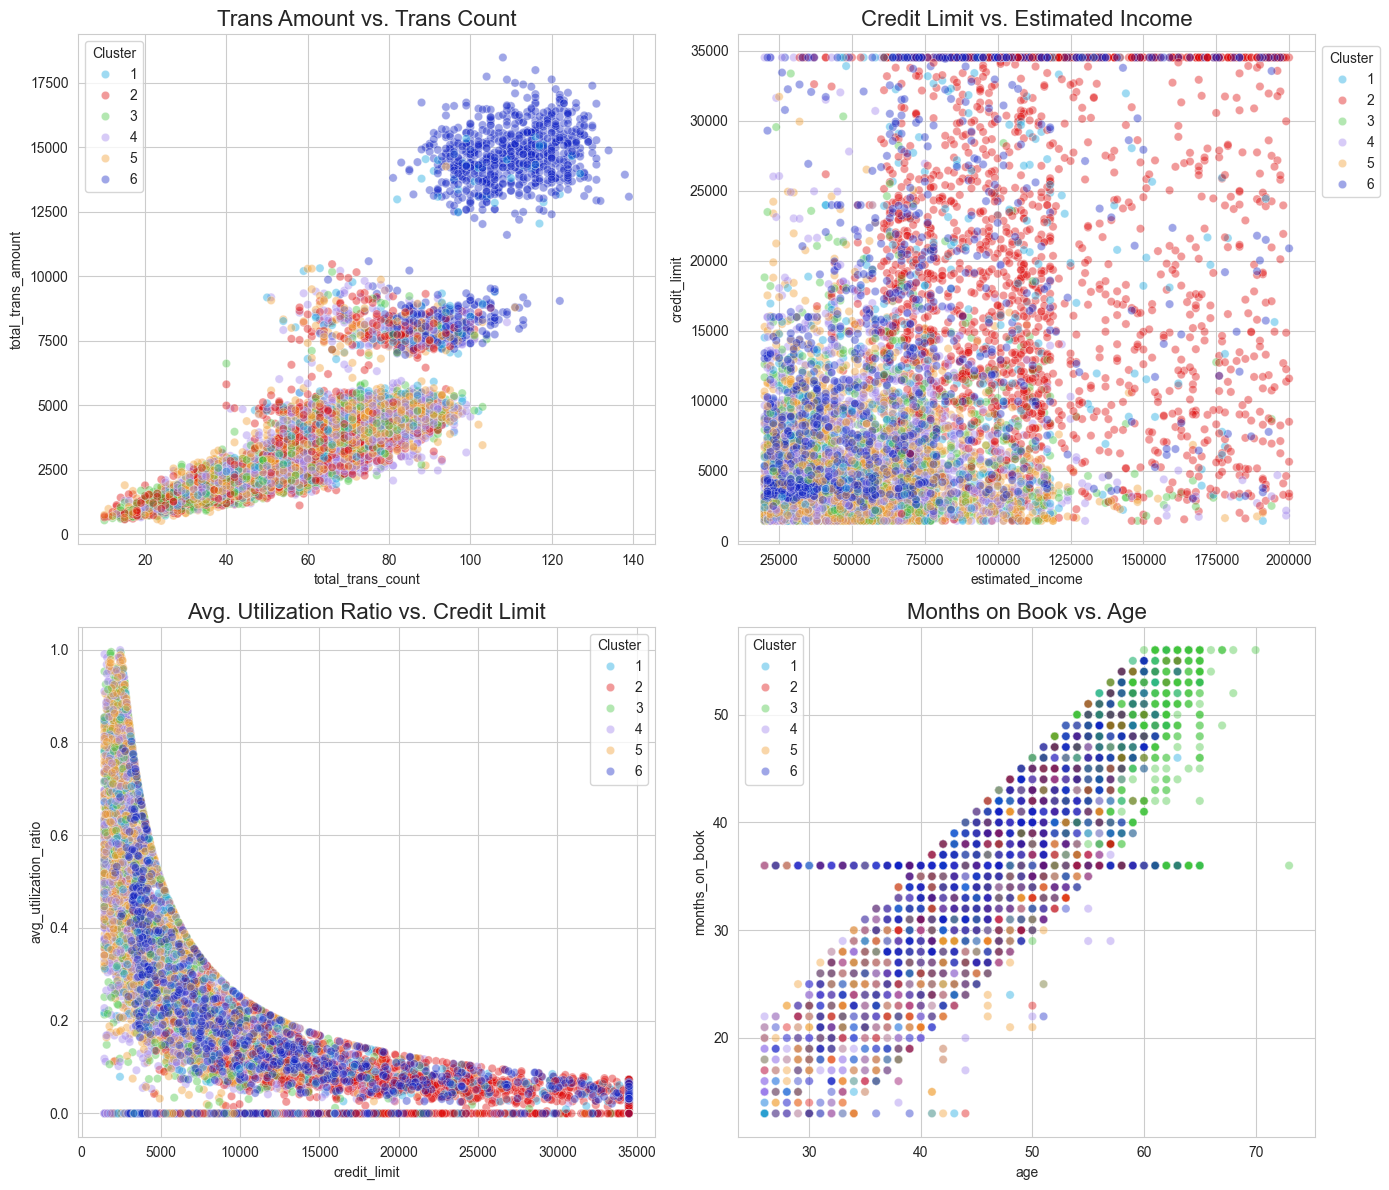

In [22]:
palette = ["#0da4e0", "#dd0404", "#42c43d", "#9c7feb", "#f09a29", "#1022c4"]

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 12))

sns.scatterplot(x="total_trans_count", y="total_trans_amount", hue="cluster", alpha=0.4, data=customers, palette=palette, legend=True, ax=ax1)
ax1.legend(title="Cluster")
ax1.set_title("Trans Amount vs. Trans Count", fontsize=16)

sns.scatterplot(x="estimated_income", y="credit_limit", hue="cluster", alpha=0.4, data=customers, palette=palette, legend=True, ax=ax2)
ax2.legend(bbox_to_anchor=(1, 0.99), title="Cluster")
ax2.set_title("Credit Limit vs. Estimated Income", fontsize=16)

sns.scatterplot(x="credit_limit", y="avg_utilization_ratio", hue="cluster", alpha=0.4, data=customers, palette=palette, legend=True, ax=ax3)
ax3.legend(title="Cluster")
ax3.set_title("Avg. Utilization Ratio vs. Credit Limit", fontsize=16)

sns.scatterplot(x="age", y="months_on_book", hue="cluster", alpha=0.4, data=customers, palette=palette, legend=True, ax=ax4)
ax4.legend(title="Cluster")
ax4.set_title("Months on Book vs. Age", fontsize=16)

plt.tight_layout()
plt.show()

This corroborates a number of the characteristics identified for each cluster listed above:

* Cluster six consists of customers with a high volume of transactions and the largest total transaction amounts.
* Cluster two consists of mid to high income customers with a range of credit limits.
* Cluster five consists of customers with relatively low credit limits, lower incomes and higher average utilization ratios.
* Cluster three consists of the older customers.

### Aggregating Categorical Columns by Cluster

In [23]:
gender_tab = pd.crosstab(index=customers["cluster"], columns=customers["gender"], values=customers["gender"], aggfunc="count", normalize="index")

gender_tab

gender,F,M
cluster,,
1,0.517147,0.482853
2,0.033090,0.966910
3,0.610803,0.389197
4,0.704128,0.295872
5,0.710124,0.289876
6,0.349835,0.650165


In [24]:
marital_status_tab = pd.crosstab(index=customers["cluster"], columns=customers["marital_status"], values=customers["marital_status"], aggfunc="count", normalize="index")

marital_status_tab

marital_status,Divorced,Married,Single,Unknown
cluster,,,,
1,0.000000,0.000000,0.000000,1.000000
2,0.110488,0.507572,0.381941,0.000000
3,0.074792,0.622576,0.302632,0.000000
4,0.000000,0.000000,1.000000,0.000000
5,0.128597,0.871403,0.000000,0.000000
6,0.089109,0.473047,0.415842,0.022002


In [25]:
education_level_tab = pd.crosstab(index=customers["cluster"], columns=customers["education_level"], values=customers["education_level"], aggfunc="count", normalize="index")

education_level_tab

education_level,College,Doctorate,Graduate,High School,Post-Graduate,Uneducated
cluster,,,,,,
1,0.112483,0.041152,0.353909,0.240055,0.079561,0.172840
2,0.118901,0.050477,0.350533,0.245093,0.057768,0.177229
3,0.114266,0.063712,0.366343,0.227147,0.054709,0.173823
4,0.114834,0.055578,0.365345,0.231712,0.059256,0.173273
5,0.123979,0.049023,0.375133,0.222025,0.064298,0.165542
6,0.113311,0.046205,0.355336,0.240924,0.055006,0.189219


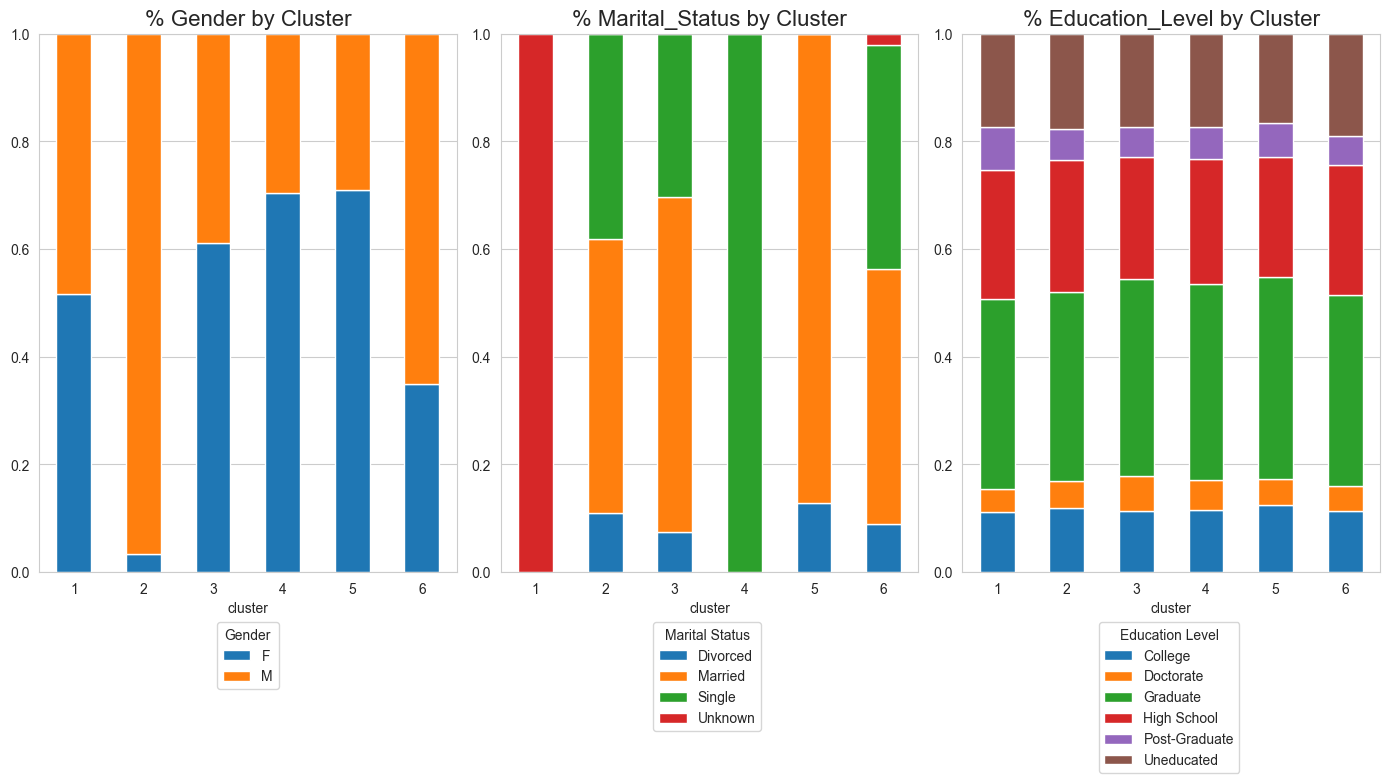

In [26]:
plot_dfs = [gender_tab, marital_status_tab, education_level_tab]
plot_num = [0, 1, 2]

fig, axes = plt.subplots(1, 3, figsize=(14, 8))

ax = axes.ravel()

for i, plot_df in zip(plot_num, plot_dfs):
  plot_df.plot(kind="bar", stacked=True, rot=0, ax=ax[i])

ax[0].set_title("% Gender by Cluster", fontsize=16)
ax[0].set_ylim(0, 1)
ax[0].legend(bbox_to_anchor=(0.59, -0.08), title="Gender")

ax[1].set_title("% Marital_Status by Cluster", fontsize=16)
ax[1].legend(bbox_to_anchor=(0.64, -0.08), title="Marital Status")

ax[2].set_title("% Education_Level by Cluster", fontsize=16)
ax[2].set_ylim(0, 1)
ax[2].legend(bbox_to_anchor=(0.68, -0.08), title="Education Level")

plt.tight_layout()
plt.show()

### Remarks on the Categorical Columns

* Cluster 2 consists of 96.7% male customers
* Cluster 1 and Cluster 4 consist entirely of customers with marital status "unknown" and "single" respectively.
* Cluster 5 mainly consists of customers with marital status "married" (87.1%).
* Education level is evenly spread across all clusters.


Insights from the categorical column aggregation can now be added to the list of cluster characteristics.

---

## Cluster Characteristics

**Cluster 1 (7.2% of the customer base)**

* Moderate income customers (US$60,000)
* Modest credit limits (US$9,157)
* Relatively large utilization ratios (0.259)

 - Roughly even spread of Males and Females (51.7% F, 48.3% M)
 - Unspecified marital status (100%)

 >Men and women which use a sizable proportion of their available credit and typically have moderate limits. This is a smaller cluster.

**Cluster 2 (17.6% of the customer base)**

* High income customers (US$114,480)
* Large credit limits (US$20,188)
* Lowest utilization ratios (0.075)

 - Majority male (96.7%)
 - Mostly "single" and "married" customers (89.0%)

 >These customers have a high volume spent on their card(s), but do not use it on a daily basis. This cluster could be incentivized to spend more.

**Cluster 3 (14.3% of the customer base)**

* Older people (57.3 years old)
* Customers that have been on the books for the longest (46.1 months)
* Customers with the fewest number of dependents (1.15)
* Relatively low income customers (US$50,686)
* Low credit limits (US$4,872)
* Large utilization ratios (0.349)

 - Slight majority female (61.1%)
 - Mostly "single" and "married" customers (92.4%)

 >Older people and long-time customers. Lower credit limits and transaction amounts, but use the card often. Could receive benefits or perks to encourage larger transaction amounts.

**Cluster 4 (24.2% of the customer base)**

* Low income customers (US$46,871)
* Low credit limits (US$4,929)
* Large utilization ratios (0.329)

 - Majority female (70.4%)
 - "Single" marital status (100%)

 >Single (mostly female) customers which use their card(s) often, but have lower incomes and credit limits. Could potentially give some of these customers higher credit limits.

**Cluster 5 (27.8% of the customer base)**

* Customers with the greatest number of dependents (2.66)
* Low income customers (US$45,854)
* Low credit limits (US$4,370)
* Large utilization ratios (0.356)

 - Majority female (71.0%)
 - Majority "married" marital status (87.1%)

 >Married (majority women) with low income and low credit limit. Their high utilization ratio comes from making few large purchases.

**Cluster 6 (9.0% of the customer base)**

* Relatively high income customers (US$68,930)
* Customers who have contacted the company the least (2.18 times)
* Relatively high credit limits (US$14,685)
* Customers who use their card(s) most frequently (108.9 transactions)
* Customers with the largest transaction amounts (US$13,313)
* Moderate utilization ratios (0.167)

 - Majority male (65.0%)
 - Mostly "single" and "married" customers (88.8%)

 >Majority male customers with relatively high income and limits, but do not use the card for large purchases. These customers could be incentivized to spend more when using their card(s). This is a smaller cluster.